In [ ]:
import sys
import os

# Always anchor relative to THIS file's location
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    #sys.path.insert(0, src_path)

import numpy as np
import torch
from scipy.optimize import minimize
import matplotlib.pyplot as plt


!python ../src/data_generation.py
!python ../src/ml_model.py
from vqe import cost_function
from ml_model import VQEModel

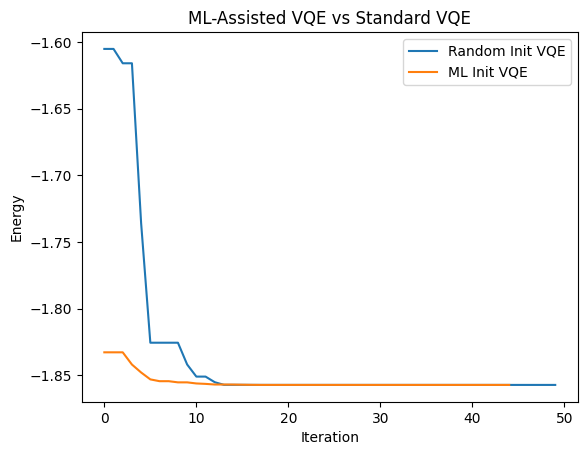

In [15]:
# -------------------------
# Load trained ML model
# -------------------------
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
MODEL_PATH = PROJECT_ROOT / "data" / "vqe_model.pth"
model = VQEModel()
model.load_state_dict(torch.load(MODEL_PATH))

#model.load_state_dict(torch.load("data/vqe_model.pth"))
model.eval()

# -------------------------
# Helper: run VQE
# -------------------------

def run_vqe(theta_init):

    energies = []

    def callback(xk):
        e = cost_function(xk)
        energies.append(e)

    result = minimize(
        cost_function,
        theta_init,
        method="COBYLA",
        callback=callback
    )

    return energies


# -------------------------
# 1. Baseline VQE
# -------------------------

theta_random = np.random.uniform(0, 2*np.pi, 4)

baseline_energies = run_vqe(theta_random)


# -------------------------
# 2. ML-assisted VQE
# -------------------------

theta_input = torch.tensor(theta_random, dtype=torch.float32)

with torch.no_grad():
    theta_ml = model(theta_input).numpy()

ml_energies = run_vqe(theta_ml)


# -------------------------
# Plot comparison
# -------------------------

plt.plot(baseline_energies, label="Random Init VQE")
plt.plot(ml_energies, label="ML Init VQE")

plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("ML-Assisted VQE vs Standard VQE")
plt.legend()

plt.show()